In [1]:
import pandas as pd 
df =pd.read_csv("amazon2.csv")
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             ₹39

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,1464.0,4.096585,0.291674,2.0,4.0,4.1,4.3,5.0
rating_count,1463.0,18295.541353,42753.864952,2.0,1186.0,5179.0,17336.5,426973.0


In [2]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [4]:
df.shape

(1465, 16)

In [5]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["review_content"].apply(get_sentiment)

print(df["sentiment"].value_counts())

sentiment
Positive    1438
Negative      26
Neutral        1
Name: count, dtype: int64


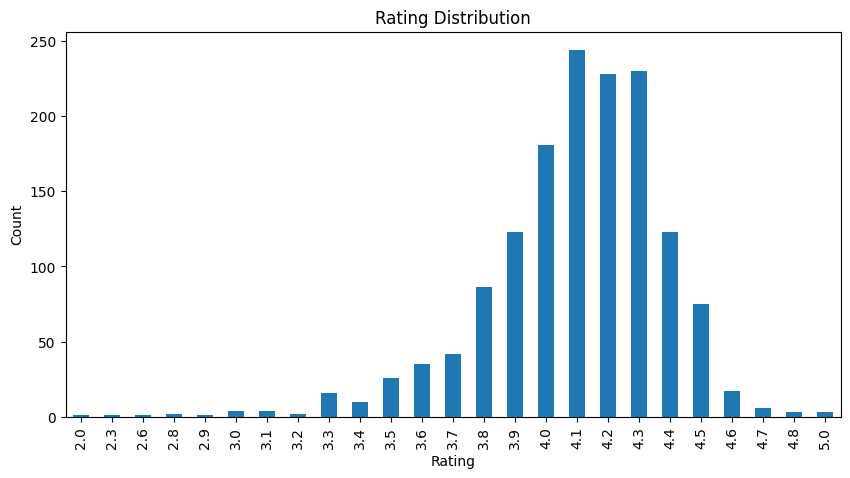

In [25]:
plt.figure(figsize=(10,5))

df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

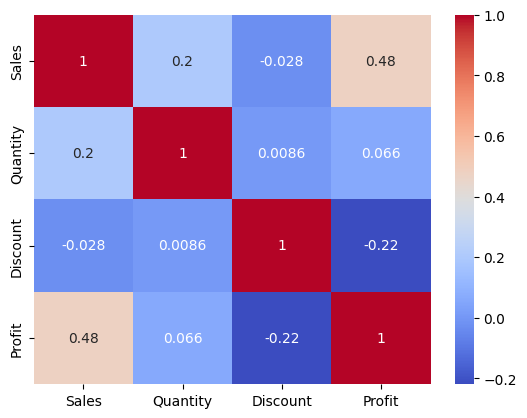

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df[["Sales", "Quantity", "Discount", "Profit"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [7]:
df["rating_count"] = (df["rating_count"].astype(str).str.replace(",", ""))

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

top_products = df.sort_values(by="rating_count",ascending=False)[["product_name", "rating_count"]]

print(top_products.head(10))

                                          product_name  rating_count
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...      426973.0
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...      426973.0
12   AmazonBasics Flexible Premium HDMI Cable (Blac...      426973.0
684  AmazonBasics Flexible Premium HDMI Cable (Blac...      426972.0
400  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0
352  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0
584  boAt BassHeads 100 in-Ear Wired Headphones wit...      363711.0
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...      313836.0
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...      313836.0
566  Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...      313832.0


sentiment
Positive    1438
Negative      26
Neutral        1
Name: count, dtype: int64


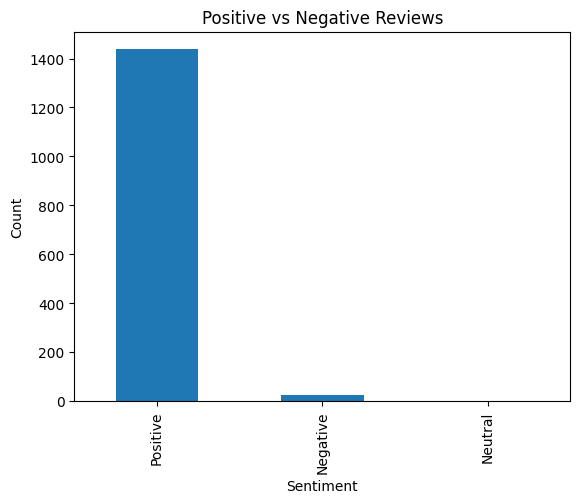

In [8]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment_counts.plot(kind="bar")
plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

[('good', 6455), ('product', 3947), ('but', 3608), ('not', 3424), ('you', 2877), ('very', 2549), ('quality', 2417), ('my', 2250), ('have', 2142), ('are', 1808), ('use', 1730), ('can', 1676), ('one', 1456), ('price', 1393), ('cable', 1380), ('at', 1379), ('like', 1243), ('or', 1230), ('also', 1225), ('from', 1222)]


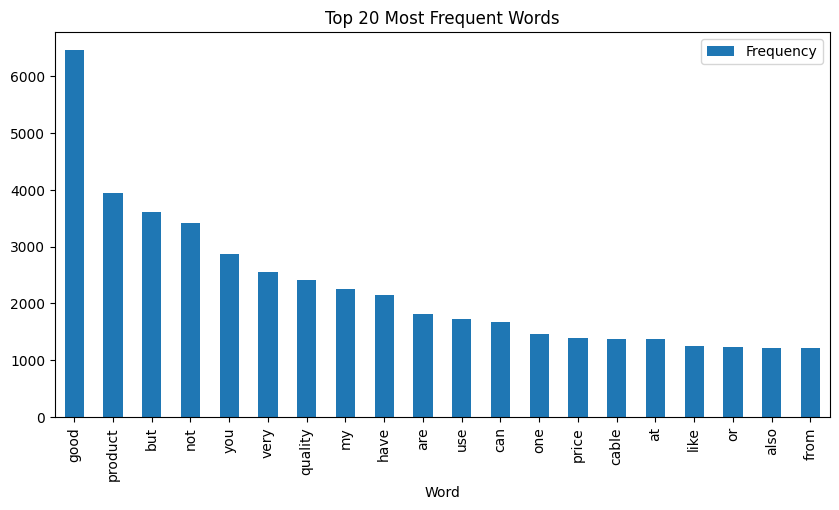

In [14]:
from collections import Counter
import re

text = " ".join(df["review_content"].astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

stop_words = {"the","and","is","to","of","it","for","this","that","in","a","an","on","with","i","was","s","as","so","if","t","be"}

words = [word for word in words if word not in stop_words]

word_freq = Counter(words)

print(word_freq.most_common(20))

freq_df = pd.DataFrame( word_freq.most_common(20),columns=["Word","Frequency"])

freq_df.plot(x="Word",y="Frequency",kind="bar",figsize=(10,5))

plt.title("Top 20 Most Frequent Words")
plt.show()